In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import scipy
import zarr

In [39]:
# List the zarr contents
data_path = Path("/workspace/diffmeshopt/data/20289/denoised/")


tomo_path = data_path / "tomo_10A.pkl"

if tomo_path.exists():
    tomo_data = joblib.load(tomo_path)
    print("Loaded tomo data from pkl file.")
else:
    zarr_file = data_path / "24apr03a_Position_100_3.zarr"
    g = zarr.open_group(zarr_file, mode="r")
    for i in g.attrs["multiscales"][0]["datasets"]:
        print(i["coordinateTransformations"])
        print(i["path"])
        # path = i["path"]
        # x = zarr.open(f"{data_path}/{path}")
        # print(x.info_items())
    tomo_data = g["1"][:]
    joblib.dump(tomo_data, tomo_path)
    print("Saved tomo data in pkl file.")

Loaded tomo data from pkl file.


In [14]:
mem_path = "/workspace/diffmeshopt/data/20289/denoised/membrane-1.0_segmentationmask.zarr"
mem_zarr = zarr.open_group(mem_path, mode="r")

In [40]:
org_path = "/workspace/diffmeshopt/data/20289/denoised/intracellular_membrane_bounded_organelle-1.0_segmentationmask.zarr"
org_zarr = zarr.open_group(org_path, mode="r")

In [41]:
membrane = mem_zarr["1"][:]
organelle = org_zarr["1"][:]


In [61]:
tomo_avg30A = scipy.ndimage.uniform_filter1d(tomo_data, 3, axis=0)

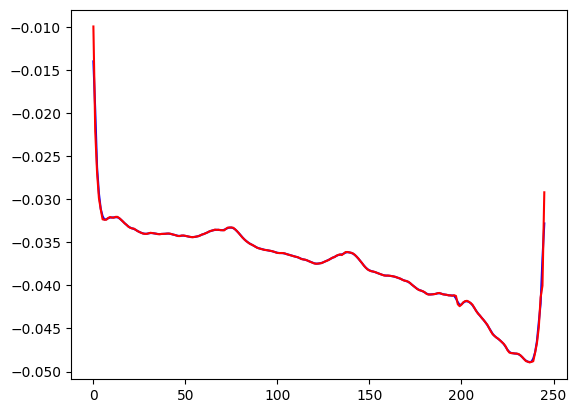

In [62]:
plt.plot(tomo_avg30A.sum(axis=(1, 2)), color="blue")
plt.plot(tomo_data.sum(axis=(1, 2)), color="red")

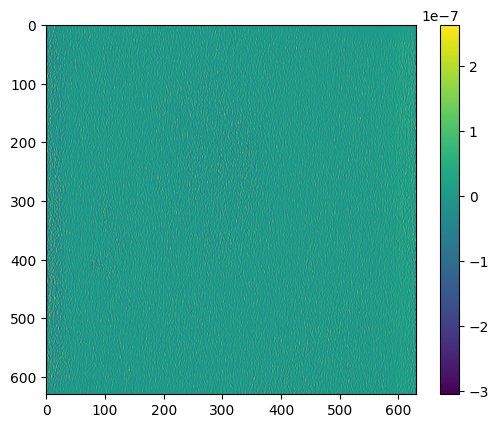

In [64]:
plt.imshow(tomo_avg30A[2] - tomo_data[2])
plt.colorbar()

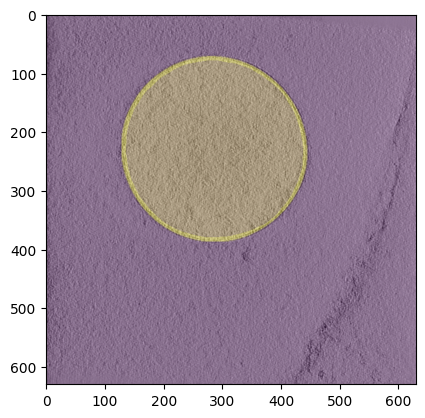

In [65]:
plt.imshow(tomo_avg30A[123], cmap="gray")
plt.imshow(membrane[123], alpha=0.2)
plt.imshow(organelle[123], alpha=0.2)

In [ ]:
data_slice123 = {
    "tomo_avg30A": tomo_data[123],
    "membrane": membrane[123],
    "organelle": organelle[123],
}
joblib.dump(data_slice123, data_path / "data_slice123.pkl")

['/workspace/diffmeshopt/data/20289/denoised/data_slice123.pkl']

: 